# Feature Engineering – RFM Analysis

This notebook focuses on transforming transactional data into
customer-level features using the RFM (Recency, Frequency, Monetary) framework.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

This notebook reloads and preprocesses the dataset to ensure reproducibility.


In [5]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

The reference date was defined as one day after the last transaction date
to calculate recency consistently.


In [6]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

Total transaction value was calculated to enable monetary aggregation.


In [8]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).reset_index()

In [9]:
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


RFM features were calculated at the customer level to summarize purchasing behavior.


In [10]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


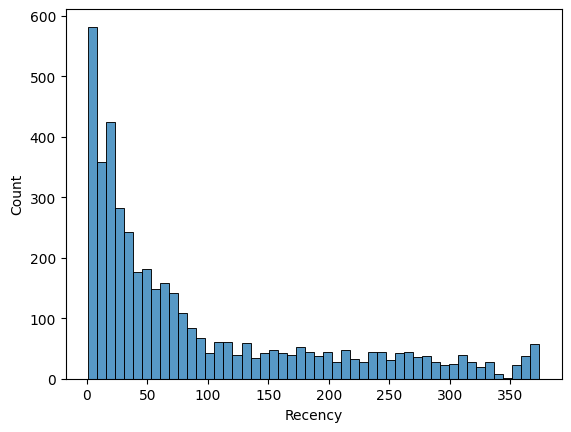

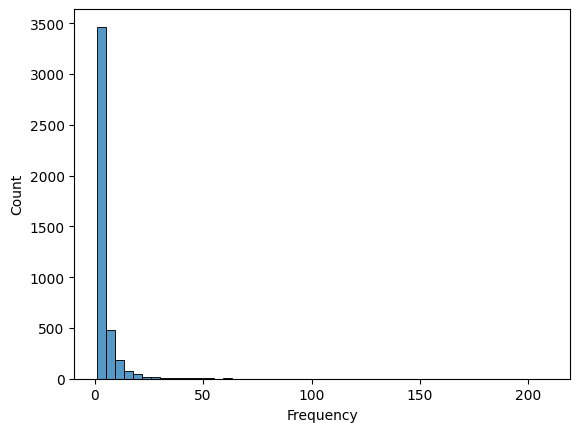

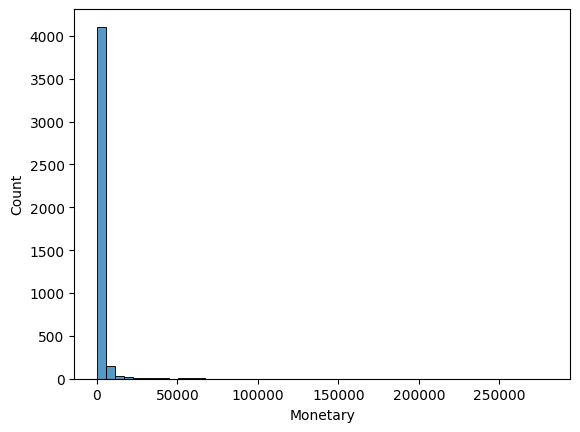

In [13]:
sns.histplot(rfm["Recency"], bins=50)
plt.show()

sns.histplot(rfm["Frequency"], bins=50)
plt.show()

sns.histplot(rfm["Monetary"], bins=50)
plt.show()


All RFM features show skewed distributions, which is common in customer transaction data.


In [14]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])


Log transformation was applied to reduce skewness while preserving relative differences.


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

Standard scaling was applied to ensure equal contribution of each feature.


## Conclusion

The transactional dataset has been successfully transformed into
customer-level RFM features. The resulting dataset is now suitable
for clustering and segmentation analysis.
